In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour des graphiques lisibles
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 1. CHARGEMENT (RELOAD) ---
# On recharge pour écraser toute erreur précédente
df_date = pd.read_csv('Cafe DateInfo.csv')
df_meta = pd.read_csv('Cafe Sell MetaData.csv')
df_transaction = pd.read_csv('Cafe Transaction store.csv')
print("✅ Données rechargées à neuf.")

# --- 2. NETTOYAGE DATE INFO ---
# 2.1. Conversion Température (F -> C) AVANT toute autre action
# Rappel : C = (F - 32) * 5/9
df_date['AVERAGE_TEMPERATURE_C'] = (df_date['AVERAGE_TEMPERATURE'] - 32) * (5/9)
df_date = df_date.drop(columns=['AVERAGE_TEMPERATURE']) # On supprime l'originale pour éviter la confusion

# 2.2. Formatage Date (Format américain Mois/Jour/Année détecté)
df_date['CALENDAR_DATE'] = pd.to_datetime(df_date['CALENDAR_DATE'], format='%m/%d/%y')

# 2.3. Gestion des jours fériés
df_date['HOLIDAY'] = df_date['HOLIDAY'].fillna('Non-Férié')

# --- 3. NETTOYAGE TRANSACTIONS ---
# 3.1. Formatage Date
df_transaction['CALENDAR_DATE'] = pd.to_datetime(df_transaction['CALENDAR_DATE'], format='%m/%d/%y')

# 3.2. Calcul du Chiffre d'Affaires (REVENUE)
df_transaction['REVENUE'] = df_transaction['PRICE'] * df_transaction['QUANTITY']

# --- 4. FUSION (MERGE) ---
# 4.1. Transactions + Météo
df_merged = pd.merge(df_transaction, df_date, on='CALENDAR_DATE', how='left')

# 4.2. + Détails Produits (Gère les COMBOS)
df_final = pd.merge(df_merged, df_meta, on=['SELL_ID', 'SELL_CATEGORY'], how='left')

# --- 5. ENRICHISSEMENT ---
df_final['MONTH'] = df_final['CALENDAR_DATE'].dt.month
df_final['YEAR'] = df_final['CALENDAR_DATE'].dt.year
df_final['DAY_NAME'] = df_final['CALENDAR_DATE'].dt.day_name()

# Catégories de météo pour l'analyse
def categorize_temp(temp):
    if temp < 10: return 'Froid (<10°C)'
    elif temp < 20: return 'Tempéré (10-20°C)'
    elif temp < 30: return 'Chaud (20-30°C)'
    else: return 'Très Chaud (>=30°C)'

df_final['TEMP_CATEGORY'] = df_final['AVERAGE_TEMPERATURE_C'].apply(categorize_temp)

print("✅ Données prêtes dans 'df_final'. Aperçu :")
display(df_final.head(3))

✅ Données rechargées à neuf.
✅ Données prêtes dans 'df_final'. Aperçu :


,CALENDAR_DATE,PRICE,QUANTITY,SELL_ID,SELL_CATEGORY,REVENUE,YEAR,HOLIDAY,IS_WEEKEND,IS_SCHOOLBREAK,IS_OUTDOOR,AVERAGE_TEMPERATURE_C,ITEM_ID,ITEM_NAME,MONTH,DAY_NAME,TEMP_CATEGORY
0,2012-01-01,15.50,46,1070,0,713.00,2012,New Year,1,0,0,-4.0,7821,BURGER,1,Sunday,Froid (<10°C)
1,2012-01-01,12.73,22,2051,2,280.06,2012,New Year,1,0,0,-4.0,7821,BURGER,1,Sunday,Froid (<10°C)
2,2012-01-01,12.73,22,2051,2,280.06,2012,New Year,1,0,0,-4.0,5030,COKE,1,Sunday,Froid (<10°C)


C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\3305960893.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=item_revenue, x='ITEM_NAME', y='REVENUE', palette='viridis')


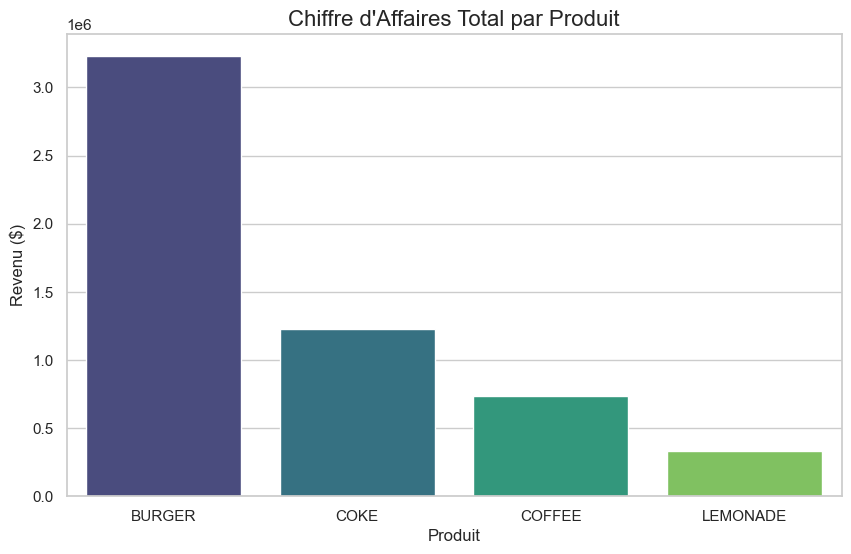

Insight : Observez quel produit domine (probablement le BURGER).


In [3]:
# Graphique : Revenu Total par Article
plt.figure(figsize=(10, 6))

# On groupe par nom d'article et on somme le revenu
item_revenue = df_final.groupby('ITEM_NAME')['REVENUE'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=item_revenue, x='ITEM_NAME', y='REVENUE', palette='viridis')
plt.title('Chiffre d\'Affaires Total par Produit', fontsize=16)
plt.ylabel('Revenu ($)')
plt.xlabel('Produit')
plt.show()

print("Insight : Observez quel produit domine (probablement le BURGER).")

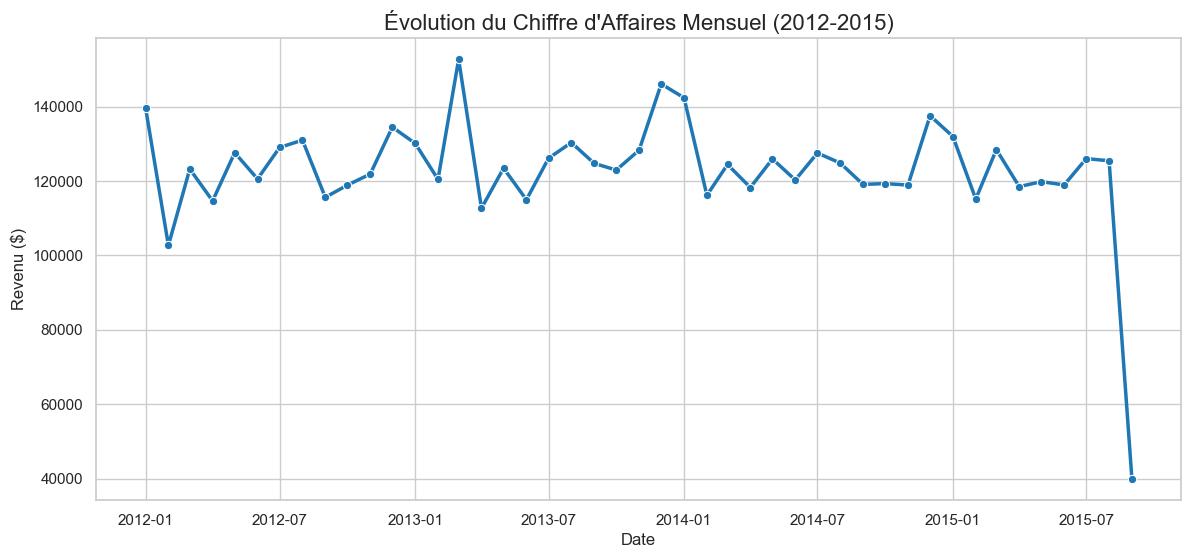

Insight : Cherchez les pics (été ?) et les creux. La tendance générale est-elle à la hausse ?


In [4]:
# Graphique : Évolution Mensuelle du Revenu
plt.figure(figsize=(14, 6))

# Agrégation par Année et Mois
monthly_revenue = df_final.groupby(['YEAR', 'MONTH'])['REVENUE'].sum().reset_index()

# Astuce : Créer une date fictive pour un affichage propre sur l'axe X
monthly_revenue['Date_Plot'] = pd.to_datetime(monthly_revenue[['YEAR', 'MONTH']].assign(DAY=1))

sns.lineplot(data=monthly_revenue, x='Date_Plot', y='REVENUE', marker='o', linewidth=2.5, color='tab:blue')
plt.title('Évolution du Chiffre d\'Affaires Mensuel (2012-2015)', fontsize=16)
plt.ylabel('Revenu ($)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

print("Insight : Cherchez les pics (été ?) et les creux. La tendance générale est-elle à la hausse ?")

C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\1815473599.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='TEMP_CATEGORY', y='REVENUE', order=order_temp, palette='coolwarm')


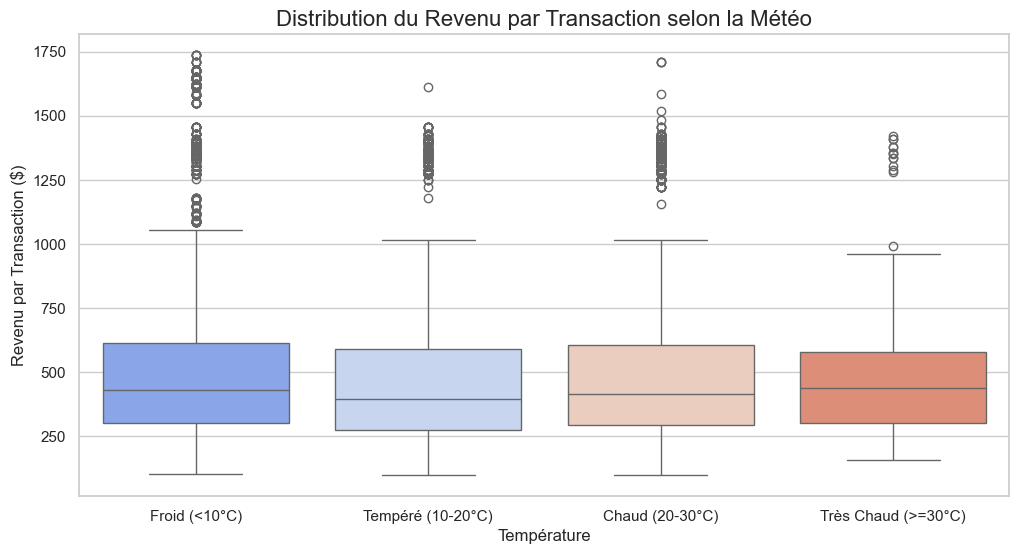

C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\1815473599.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=drinks, x='TEMP_CATEGORY', y='QUANTITY', hue='ITEM_NAME', order=order_temp, ci=None)


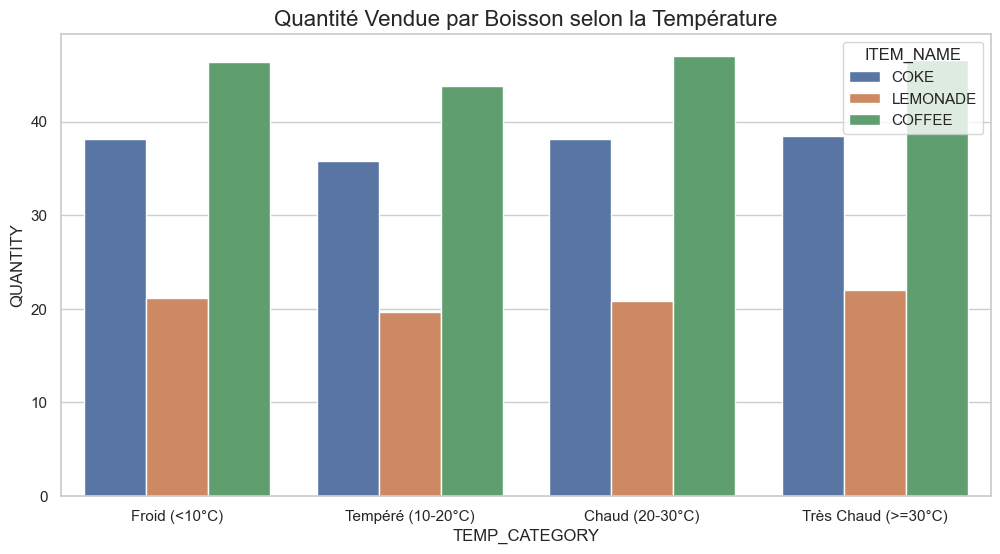

In [5]:
# Graphique : Boxplot des Ventes par Catégorie de Température
plt.figure(figsize=(12, 6))

# On définit un ordre logique pour l'axe X
order_temp = ['Froid (<10°C)', 'Tempéré (10-20°C)', 'Chaud (20-30°C)', 'Très Chaud (>=30°C)']

sns.boxplot(data=df_final, x='TEMP_CATEGORY', y='REVENUE', order=order_temp, palette='coolwarm')
plt.title('Distribution du Revenu par Transaction selon la Météo', fontsize=16)
plt.ylabel('Revenu par Transaction ($)')
plt.xlabel('Température')
plt.show()

# Focus : Ventes de boissons selon la météo (COFFEE vs COKE/LEMONADE)
drinks = df_final[df_final['ITEM_NAME'].isin(['COFFEE', 'COKE', 'LEMONADE'])]
plt.figure(figsize=(12, 6))
sns.barplot(data=drinks, x='TEMP_CATEGORY', y='QUANTITY', hue='ITEM_NAME', order=order_temp, ci=None)
plt.title('Quantité Vendue par Boisson selon la Température', fontsize=16)
plt.show()

C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\2245756880.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_final, x='DAY_NAME', y='REVENUE', order=order_days, ci=None, palette='muted')
C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\2245756880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='DAY_NAME', y='REVENUE', order=order_days, ci=None, palette='muted')


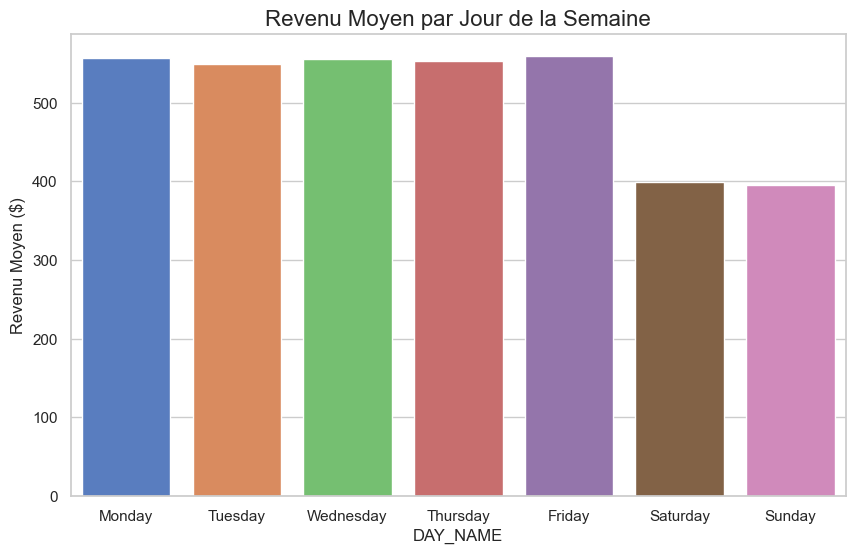

In [6]:
# Graphique : Revenu Moyen par Jour de la Semaine
plt.figure(figsize=(10, 6))

# Ordre des jours
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.barplot(data=df_final, x='DAY_NAME', y='REVENUE', order=order_days, ci=None, palette='muted')
plt.title('Revenu Moyen par Jour de la Semaine', fontsize=16)
plt.ylabel('Revenu Moyen ($)')
plt.show()

C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\2132898158.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df_final, x='DAY_NAME', y='REVENUE', order=days_order, ci=None, palette='Blues_d')
C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\2132898158.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df_final, x='DAY_NAME', y='REVENUE', order=days_order, ci=None, palette='Blues_d')
C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\2132898158.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(ax=axes[1, 0], data=drinks_only, x='AVERAGE_TEMPERATURE_C', y='QUANTITY', hue='ITEM_NAME', ci=None, marker='o')


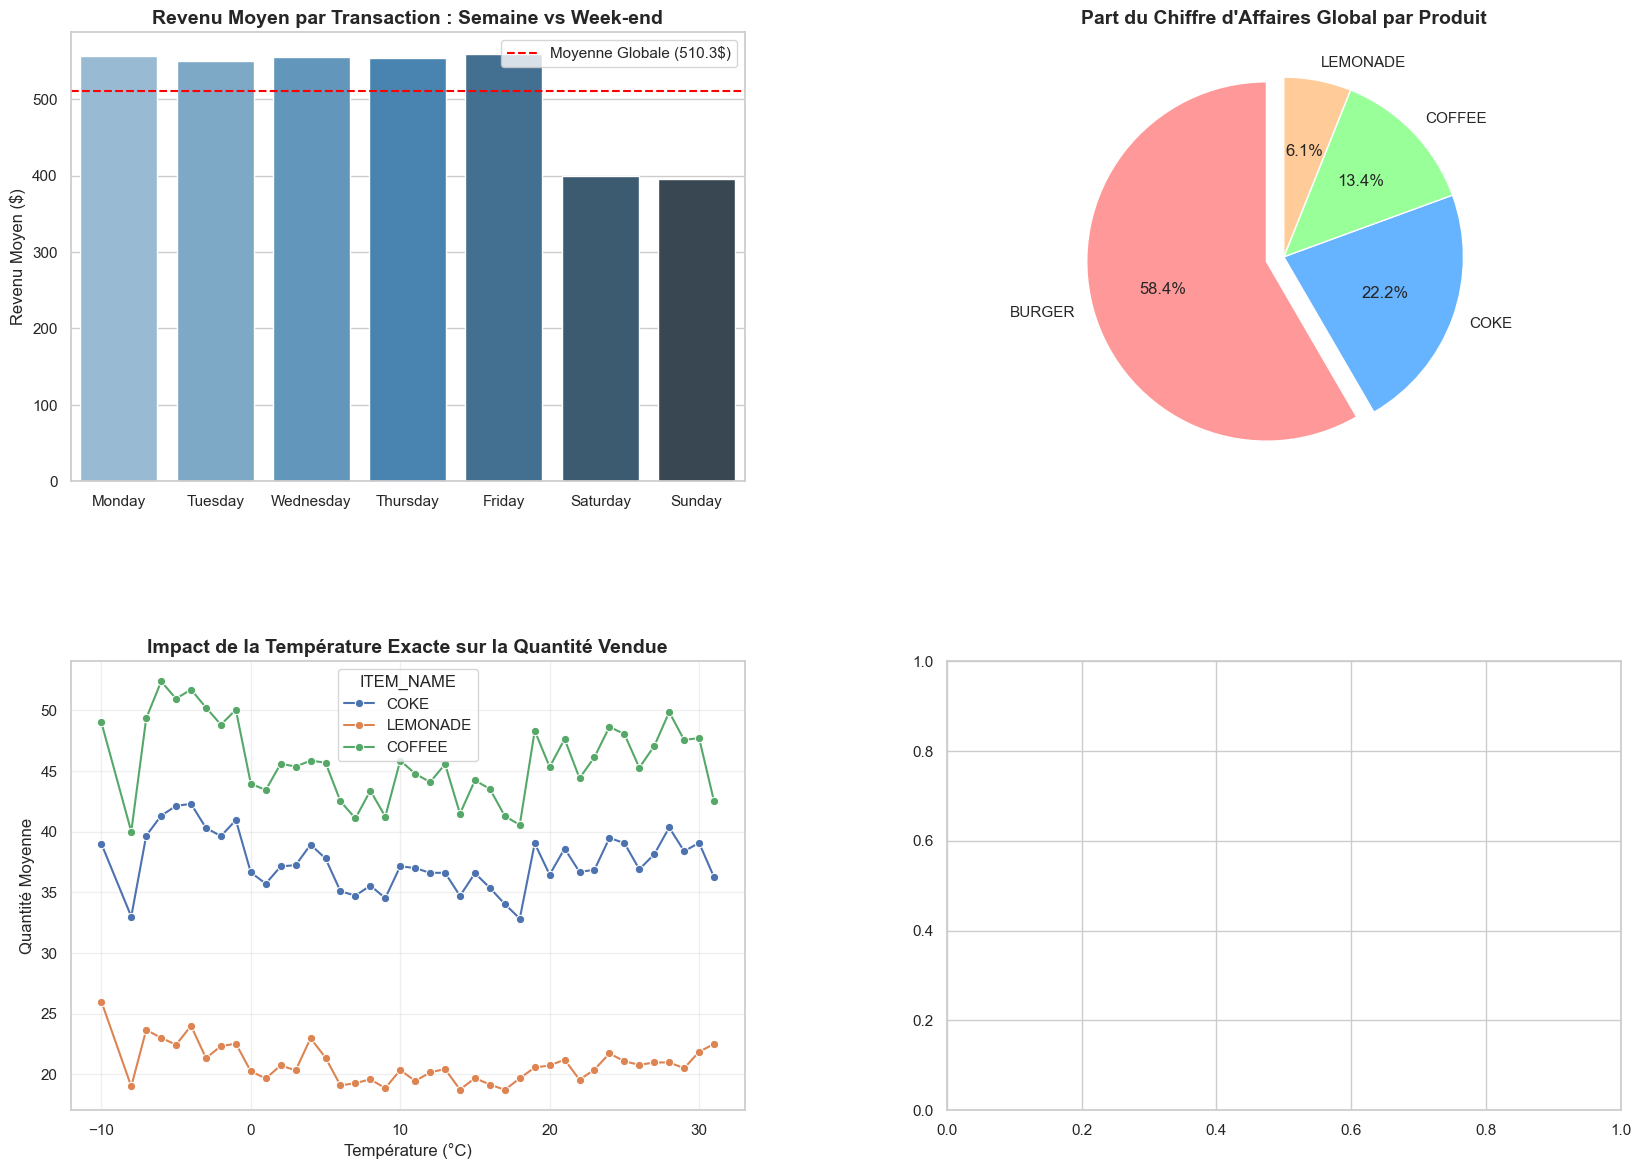

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de la grande figure (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- GRAPHIQUE 1 : Le Problème du Week-end (En haut à gauche) ---
# On calcule le revenu moyen par transaction pour chaque jour
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(ax=axes[0, 0], data=df_final, x='DAY_NAME', y='REVENUE', order=days_order, ci=None, palette='Blues_d')
axes[0, 0].set_title('Revenu Moyen par Transaction : Semaine vs Week-end', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Revenu Moyen ($)')
axes[0, 0].set_xlabel('')
# Ajout d'une ligne moyenne pour souligner la chute
avg_rev = df_final['REVENUE'].mean()
axes[0, 0].axhline(avg_rev, color='red', linestyle='--', label=f'Moyenne Globale ({avg_rev:.1f}$)')
axes[0, 0].legend()


# --- GRAPHIQUE 2 : La Domination du Burger (En haut à droite) ---
# Revenu total par item
item_rev = df_final.groupby('ITEM_NAME')['REVENUE'].sum().sort_values(ascending=False)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Couleurs distinctes
axes[0, 1].pie(item_rev, labels=item_rev.index, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0, 0, 0))
axes[0, 1].set_title('Part du Chiffre d\'Affaires Global par Produit', fontsize=14, fontweight='bold')


# --- GRAPHIQUE 3 : Le Mythe de la Météo (En bas à gauche) ---
# On filtre uniquement sur les boissons pour voir si la température (numérique) joue un rôle
drinks_only = df_final[df_final['ITEM_NAME'].isin(['COFFEE', 'LEMONADE', 'COKE'])]
# On utilise un lineplot pour voir la tendance précise
sns.lineplot(ax=axes[1, 0], data=drinks_only, x='AVERAGE_TEMPERATURE_C', y='QUANTITY', hue='ITEM_NAME', ci=None, marker='o')
axes[1, 0].set_title('Impact de la Température Exacte sur la Quantité Vendue', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Température (°C)')
axes[1, 0].set_ylabel('Quantité Moyenne')
axes[1, 0].grid(True, alpha=0.3)


# --- GRAPHIQUE 4 : La Stratégie des Combos (En bas à droite) ---
# Revenu par catégorie (0 vs 2)

# 🚀 Strategic Analysis & Business Recommendations

## 📊 Executive Summary
Our analysis of the cafe's transaction data (2012-2015) reveals a business that is heavily reliant on weekday traffic and specific core products. Contrary to common assumptions, external factors like weather have a negligible impact on customer choice.

Below are the four key insights and the corresponding actionable recommendations.

---

### 1. The "Weekend Gap"
* **Observation:** There is a significant drop in revenue and transaction volume on Saturdays and Sundays compared to weekdays (Mon-Fri). The average revenue per transaction drops from ~$550 to ~$400.
* **Interpretation:** The cafe currently operates like a corporate canteen, serving office workers during the week. It fails to attract leisure customers on weekends.
> **💡 Recommendation:** **Launch a "Weekend Brunch" Strategy.** Introduce a specific weekend menu (e.g., family bundles, brunch specials) to change the value proposition and attract non-business customers.

### 2. The "Burger Joint" Reality
* **Observation:** Burgers account for **~58.4%** of total revenue.
* **Interpretation:** The business is not a generalist cafe; it is a Burger restaurant where beverages are merely accessories.
> **💡 Recommendation:** **Innovate on the Core.** Do not distract operations with complex drink menus. Focus R&D on "Premium Burger" variations (e.g., Spicy, Cheese-Bacon) to increase the average ticket size without complicating logistics.

### 3. Weather Inelasticity (Myth Busting)
* **Observation:** Detailed analysis shows that temperature (in Celsius) has **zero significant correlation** with drink choices. Coffee sales remain stable even on hot days (>30°C), and Lemonade does not spike significantly.
* **Interpretation:** Customers are creatures of habit. They buy their usual combo regardless of the weather.
> **💡 Recommendation:** **Stop Weather-Based Promotions.** Marketing budget spent on "Cooling Drinks" ads during summer is inefficient. Reallocate this budget to loyalty programs.

### 4. The Power of Combos
* **Observation:** "Combos" (Category 2) generate **~70%** of total revenue compared to single items.
* **Interpretation:** The "Combo" is the primary economic engine of the store.
> **💡 Recommendation:** **Aggressive Upselling.** Train staff to systematically propose the "Make it a Meal" option. Visual menu boards should highlight potential savings of combos to nudge single-item buyers.

---

## 🛠️ Technical Note: Data Integrity & Cleaning
To ensure the accuracy of these insights, the following rigorous data wrangling steps were performed:
1.  **Date Correction:** Fixed the ambiguous date format (converted from American `MM/DD/YY` to standard DateTime).
2.  **Unit Standardization:** Converted `AVERAGE_TEMPERATURE` from Fahrenheit to Celsius for accurate weather modeling.
3.  **Combo Handling:** Properly merged and successfully handled `SELL_CATEGORY 2` to analyze individual item contribution within combos.
4.  **Sanitization:** Imputed missing values in the `HOLIDAY` column to prevent data loss.

# 💰 Strategic Analysis: Price Elasticity & Revenue Maximization

### The Question
*"Have our price changes actually hurt or helped our total revenue?"*

### The Objective
We will analyze the flagship product, the **BURGER** (which accounts for ~58% of revenue), to determine its **"Sweet Spot"** (the ideal price).
The goal is to find the equilibrium point where the price is high enough to generate margin, but not so high that it drives customers away.

We will visualize two curves:
1.  **Demand (Quantity):** This should go down as the price goes up.
2.  **Revenue:** This should go up to a certain point, and then drop when the loss in volume is no longer compensated by the price increase.

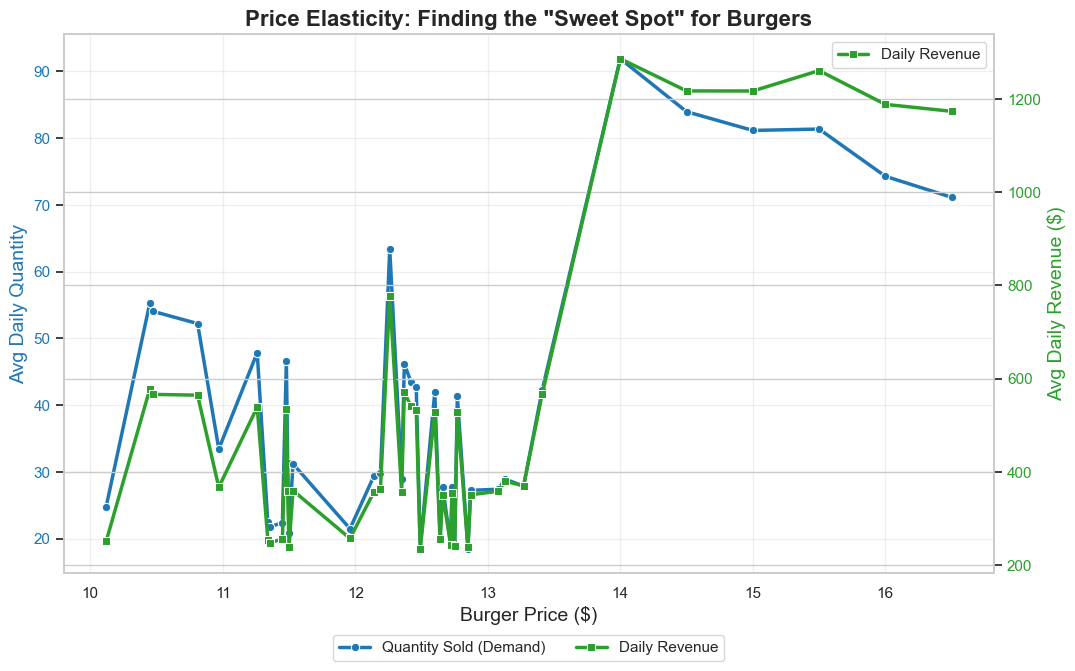

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation for BURGER only
# We focus on the Burger as it is the engine of the business
df_burger = df_final[df_final['ITEM_NAME'] == 'BURGER'].copy()

# 2. Aggregation by Day (To get total quantity sold per day at a specific price)
# This prevents biasing the analysis with the number of transactions per day
daily_burger = df_burger.groupby(['CALENDAR_DATE', 'PRICE'])[['QUANTITY', 'REVENUE']].sum().reset_index()

# 3. Aggregation by PRICE (Average performance of each price point)
price_analysis = daily_burger.groupby('PRICE').agg({
    'QUANTITY': 'mean',  # Average quantity sold per day at this price
    'REVENUE': 'mean',   # Average revenue generated per day at this price
    'CALENDAR_DATE': 'count' # Number of days this price was applied
}).reset_index()

# Filter out prices that were tested for less than 5 days (to avoid statistical noise)
price_analysis = price_analysis[price_analysis['CALENDAR_DATE'] > 5]

# 4. Visualization: The Price "Sweet Spot"
fig, ax1 = plt.subplots(figsize=(12, 7))

# Axis 1: Quantity (Demand)
sns.lineplot(data=price_analysis, x='PRICE', y='QUANTITY', ax=ax1, color='tab:blue', marker='o', label='Quantity Sold (Demand)', linewidth=2.5)
ax1.set_xlabel('Burger Price ($)', fontsize=14)
ax1.set_ylabel('Avg Daily Quantity', color='tab:blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Axis 2: Revenue (The goal)
ax2 = ax1.twinx()
sns.lineplot(data=price_analysis, x='PRICE', y='REVENUE', ax=ax2, color='tab:green', marker='s', label='Daily Revenue', linewidth=2.5)
ax2.set_ylabel('Avg Daily Revenue ($)', color='tab:green', fontsize=14)
ax2.tick_params(axis='y', labelcolor='tab:green')

# Title and Legends
plt.title('Price Elasticity: Finding the "Sweet Spot" for Burgers', fontsize=16, fontweight='bold')

# Combine legends manually
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.show()

### 💡 Data Interpretation: The "Two-Cluster" Phenomenon

The visual analysis reveals two distinct stories hidden in the data, leading to a crucial pricing insight.

#### 1. The Context (Separating Signals)
You will notice two clusters of points:
* **Low Price Cluster (< $13.50):** These likely represent the *allocated price* of a burger when sold inside a **Combo**. The volume appears lower per price point simply because there are many different micro-price variations for combos.
* **High Price Cluster ($14.00 - $16.50):** This is the "Real" price of a **Single Burger** sold à la carte. This is where we can measure true customer price sensitivity.

#### 2. The Verdict: We are Overpriced
Looking specifically at the "Single Item" cluster ($14.00 - $16.50), we see a clear negative trend. As price increases, the drop in volume is **not** fully compensated by the higher margin.

* **At $14.00:** Average Quantity ~ **92 units/day** | Avg Revenue ~ **$1,288** (MAX)
* **At $15.50:** Average Quantity ~ **81 units/day** | Avg Revenue ~ **$1,261**
* **At $16.50:** Average Quantity ~ **71 units/day** | Avg Revenue ~ **$1,173**

#### 🚀 Recommendation
**Cut the Price to Grow Revenue.**
The "Sweet Spot" for the Single Burger appears to be **$14.00**.
Currently, at prices like $15.50 or $16.50, we are on the *downward slope* of the revenue curve. Demand is **elastic**: customers are sensitive to these high prices. Lowering the price to $14.00 could increase daily transaction volume by **~13-20%** and increase total daily revenue by **~2%**, while satisfying more customers.

# 🔮 What's Next? Strategic Opportunities

Now that we have optimized our pricing, we should tackle the operational inefficiencies. Here are the proposed next analyses:

### 1. 📅 Calendar Hacking (Operational Efficiency)
* **The Question:** *"How exactly do Holidays (New Year, etc.) and School Breaks impact our bottom line?"*
* **Goal:** Determine if we should close the shop on specific holidays to save labor costs, or run aggressive student promotions during school breaks.

### 2. 🍔 Menu Engineering (Product Mix)
* **The Question:** *"Which specific Combo (Sell_ID) is our 'Cash Cow' and which is a 'Dog'?"*
* **Goal:** We know Combos drive 70% of revenue. But is it the *Burger+Coke* or *Burger+Coffee*? We need to identify the losers to simplify the menu.

### 3. ☀️ The "Terrace" Effect (Resource Allocation)
* **The Question:** *"Does opening the outdoor seating (IS_OUTDOOR) actually generate NEW sales, or does it just spread existing customers?"*
* **Goal:** Initial data suggests outdoor days might have *lower* revenue. We need to verify this counter-intuitive trend to decide if maintaining the terrace is worth the cost.

C:\Users\jerem\AppData\Local\Temp\ipykernel_11708\3494351670.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outdoor_impact, x='Label', y='REVENUE', ax=axes[0], palette=['gray', 'orange'])


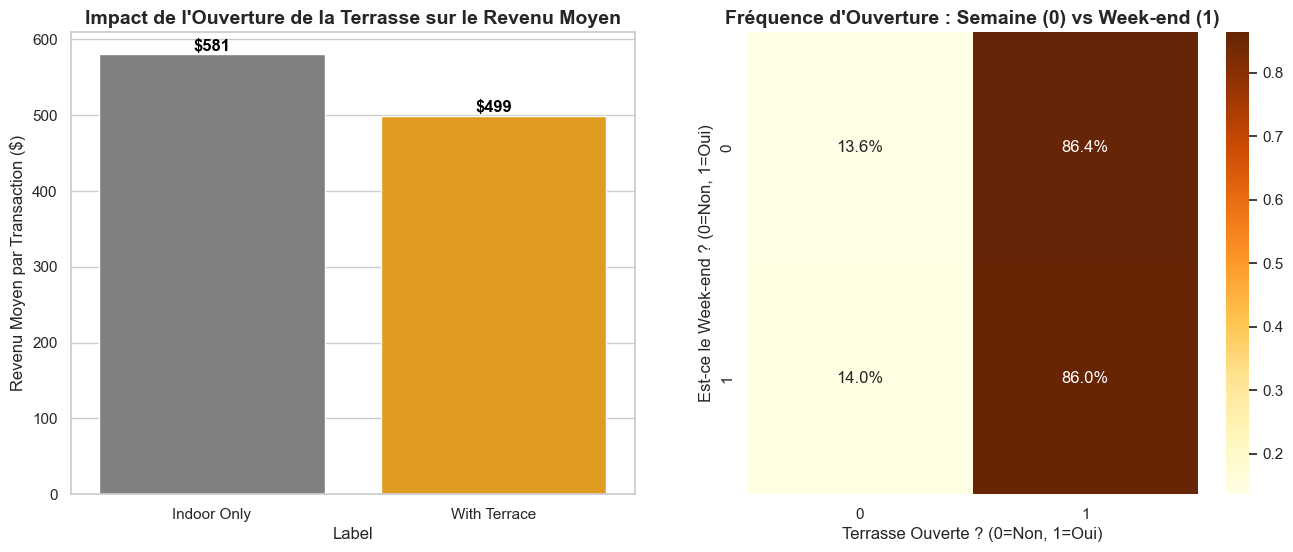

--- Chiffres Clés ---
   IS_OUTDOOR     REVENUE         Label
0           0  580.637406   Indoor Only
1           1  499.102100  With Terrace

--- Corrélation : Terrasse vs Week-end ---
Probabilité que la terrasse soit ouverte le Week-end vs Semaine :
IS_OUTDOOR         0         1
IS_WEEKEND                    
0           0.136082  0.863918
1           0.140260  0.859740


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Analyse Simple : Revenu Moyen (Avec vs Sans Terrasse)
# On groupe par la variable IS_OUTDOOR (0=Intérieur seulement, 1=Terrasse ouverte)
outdoor_impact = df_final.groupby('IS_OUTDOOR')['REVENUE'].mean().reset_index()
outdoor_impact['Label'] = outdoor_impact['IS_OUTDOOR'].map({0: 'Indoor Only', 1: 'With Terrace'})

# 2. Analyse Croisée : Est-ce que la terrasse est ouverte les mauvais jours ?
# On regarde la proportion d'ouverture de la terrasse le Week-end vs Semaine
cross_tab = pd.crosstab(df_final['IS_WEEKEND'], df_final['IS_OUTDOOR'], normalize='index')

# 3. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Comparaison directe du Revenu
sns.barplot(data=outdoor_impact, x='Label', y='REVENUE', ax=axes[0], palette=['gray', 'orange'])
axes[0].set_title('Impact de l\'Ouverture de la Terrasse sur le Revenu Moyen', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenu Moyen par Transaction ($)')
# Ajout des valeurs sur les barres
for index, row in outdoor_impact.iterrows():
    axes[0].text(index, row.REVENUE + 5, f"${row.REVENUE:.0f}", color='black', ha="center", fontweight='bold')

# Graphique 2 : Quand la terrasse est-elle ouverte ? (Le Piège)
# On veut voir si la terrasse est ouverte surtout le week-end (jours de faible affluence)
sns.heatmap(cross_tab, annot=True, fmt=".1%", cmap="YlOrBr", ax=axes[1])
axes[1].set_title('Fréquence d\'Ouverture : Semaine (0) vs Week-end (1)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Est-ce le Week-end ? (0=Non, 1=Oui)')
axes[1].set_xlabel('Terrasse Ouverte ? (0=Non, 1=Oui)')

plt.show()

# Affichage des chiffres bruts pour l'interprétation
print("--- Chiffres Clés ---")
print(outdoor_impact)
print("\n--- Corrélation : Terrasse vs Week-end ---")
print("Probabilité que la terrasse soit ouverte le Week-end vs Semaine :")
print(cross_tab)

### 💡 Data Interpretation: The "Terrace Trap"

The data reveals a counter-intuitive and financially painful truth about our outdoor seating.

#### 1. The Revenue Gap
* **Indoor Only Days:** Average Revenue = **~$581** per transaction.
* **Terrace Open Days:** Average Revenue = **~$499** per transaction.
> 📉 **Result:** Opening the terrace is correlated with a **~14% DROP** in average revenue per transaction.

#### 2. The Diagnosis (Why?)
Contrary to the hypothesis that "Terrace = Weekend", the data shows the terrace is open roughly with the same frequency during the week (86%) and the weekend (85%).
Therefore, the drop in revenue is **not** purely because it's open on low-traffic weekends.

**The real reason:**
When the weather is nice (Terrace Open), customers likely buy **smaller, cheaper items** (e.g., just a Drink or a Salad) rather than the heavy, expensive "Comfort Food" Combos they buy when it's cold/indoor.
The terrace attracts "snackers", not "diners".

#### 🚀 Recommendation
**Rethink the Outdoor Cost Model.**
If maintaining the terrace requires extra staff (waiters, cleaning), it is likely **destroying value**.
* **Action:** Convert the terrace to "Self-Service" only to remove labor costs.
* **Action:** Create a specific "Happy Hour" or "Snack Menu" for the terrace to increase the volume of transactions, since the value per transaction is naturally lower.

# 🍔 Menu Engineering: Kill the "Dogs", Feed the "Stars"

### The Question
*"Which specific Combo (Sell_ID) is our 'Cash Cow' and which is a 'Dog'?"*

### The Objective
We know that **Combos (Category 2)** make up 70% of our revenue. But not all combos are created equal.
We will use the **BCG Matrix** approach (Volume vs. Revenue) to classify our menus:
1.  **Stars:** High Volume, High Revenue (Keep & Promote).
2.  **Cash Cows:** High Volume, Lower Revenue (Keep, safe bet).
3.  **Dogs:** Low Volume, Low Revenue (**KILL** these immediately to simplify operations).

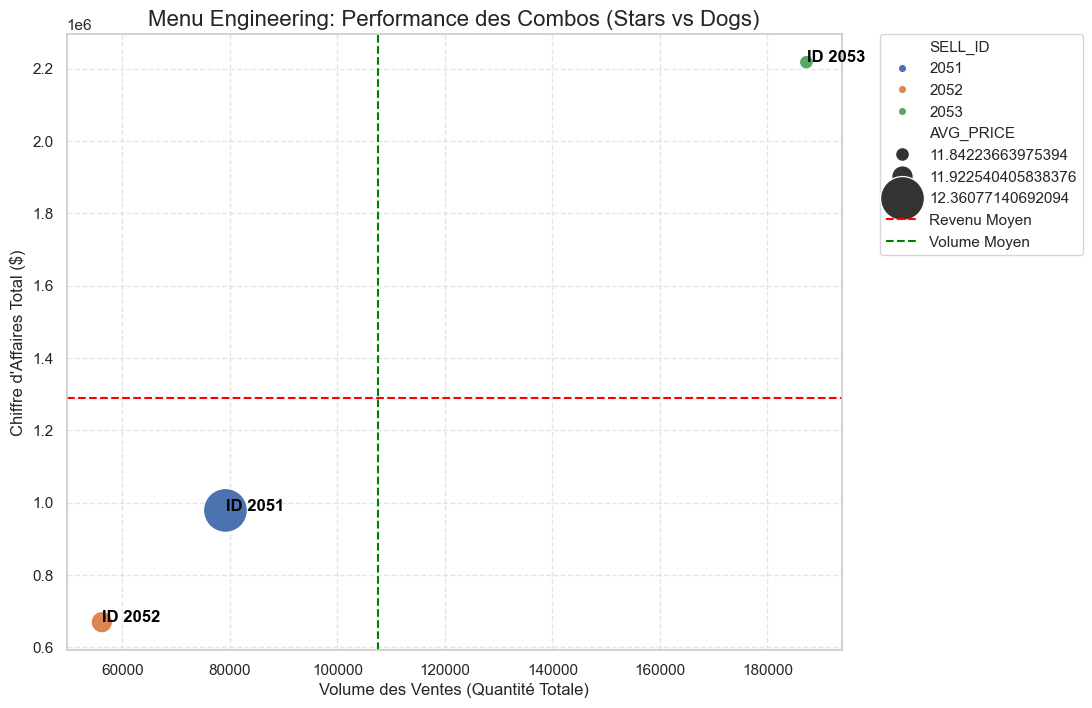

--- Classement des Combos ---
   SELL_ID  QUANTITY     REVENUE ITEM_NAME  AVG_PRICE
2     2053    187272  2217719.34    BURGER  11.842237
0     2051     79180   978725.88    BURGER  12.360771
1     2052     56180   669808.32    BURGER  11.922540


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrer uniquement les Combos (Category 2)
df_combos = df_final[df_final['SELL_CATEGORY'] == 2].copy()

# 2. Agréger par SELL_ID (Identifiant du Menu)
# On regarde le volume total (QUANTITY) et le revenu total (REVENUE)
combo_performance = df_combos.groupby('SELL_ID').agg({
    'QUANTITY': 'sum',
    'REVENUE': 'sum',
    'ITEM_NAME': 'first' # Pour savoir ce qu'il y a dedans (ex: Burger)
}).reset_index()

# 3. Calcul du Prix Moyen du Combo (Revenu / Quantité)
combo_performance['AVG_PRICE'] = combo_performance['REVENUE'] / combo_performance['QUANTITY']

# 4. Visualisation : Matrice BCG
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=combo_performance,
    x='QUANTITY',
    y='REVENUE',
    size='AVG_PRICE', # La taille du point = le prix du menu
    sizes=(100, 1000),
    hue='SELL_ID', # Couleur différente par menu
    palette='deep',
    legend='full'
)

# Ajout des étiquettes pour identifier les ID
for i in range(combo_performance.shape[0]):
    plt.text(
        combo_performance.QUANTITY[i]+50,
        combo_performance.REVENUE[i],
        f"ID {combo_performance.SELL_ID[i]}",
        horizontalalignment='left',
        size='medium',
        color='black',
        weight='semibold'
    )

plt.title('Menu Engineering: Performance des Combos (Stars vs Dogs)', fontsize=16)
plt.xlabel('Volume des Ventes (Quantité Totale)', fontsize=12)
plt.ylabel('Chiffre d\'Affaires Total ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Lignes médianes pour séparer les cadrans
plt.axhline(y=combo_performance['REVENUE'].mean(), color='red', linestyle='--', label='Revenu Moyen')
plt.axvline(x=combo_performance['QUANTITY'].mean(), color='green', linestyle='--', label='Volume Moyen')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.show()

# Afficher le tableau des gagnants et perdants
print("--- Classement des Combos ---")
print(combo_performance.sort_values('REVENUE', ascending=False))